# What is preprocessing
Data preprocessing transforms messy, raw data into a clean, structured format that machine learning algorithms can understand
1. Data Collection and Integration
    - MySQL
    - Files - excel , csv etc
2. Feature selection
3. Data Cleaning
    * missing values
    * duplicate records 
    * remove outliers
4. Feature Engineering
5. Data Transformation
6. Feature scaling
 

In [1]:
# loading imp libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

## Data Collection

### From file

In [4]:
# loading data file of house prices using file
df = pd.read_csv('house_price.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


### From MySQL

In [ ]:
from sqlalchemy import create_engine

# create a connection to the mysql database using sqlalchemy
host = 'localhost'          # set your details here
database = 'db'
user = 'root'
password = '1234'

engine = create_engine(f'mysql+mysqlconnector://{user}:{password}@{host}/{database}')

In [ ]:
pd.read_sql('SELECT * FROM house_price',engine)

In [ ]:
df.info()

In [ ]:
df.describe().round(2)

In [ ]:
# from excel file

## Detecting missing values

In [ ]:
# detecting missing values in the dataset
df.isnull().sum()

## Remove duplicates

In [9]:
# removing duplicate rows from the dataset
df = df.drop_duplicates()

# remove outliers

<Axes: >

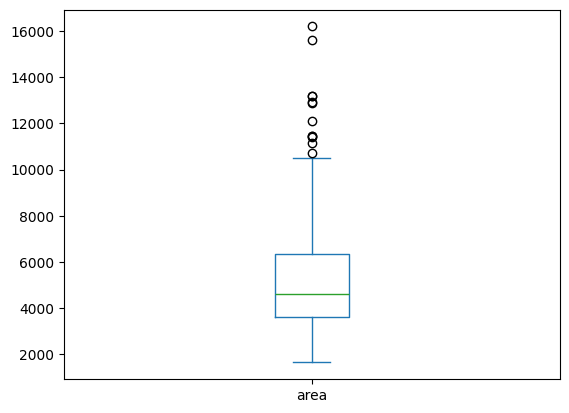

In [10]:
# Use IQR Method
df['area'].plot(kind='box')

In [11]:
df['area'].describe()

count      545.000000
mean      5150.541284
std       2170.141023
min       1650.000000
25%       3600.000000
50%       4600.000000
75%       6360.000000
max      16200.000000
Name: area, dtype: float64

In [12]:
# so we can see there are outliers need to remove them using winsorization method
quarter_5_percent = df['area'].quantile(0.05)
quarter_95_percent = df['area'].quantile(0.95)

df['area'] = np.where(df['area']>quarter_95_percent,quarter_95_percent,df['area'])
df['area'] = np.where(df['area']<quarter_5_percent,quarter_5_percent,df['area'])

In [13]:
df.area.describe()

count     545.000000
mean     5065.550459
std      1840.682265
min      2562.000000
25%      3600.000000
50%      4600.000000
75%      6360.000000
max      9000.000000
Name: area, dtype: float64

## Feature Engineering
Feature engineering is the process of using domain knowledge and statistical techniques to transform raw data into meaningful inputs (features) for machine learning models. Its goal is to highlight patterns and simplify data so algorithms can learn more effectively and make highly accurate predictions.

### Adding columns like
- total rooms
- bathroom per bedroom
- total area of all floors

In [ ]:
df.head(2)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420.0,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960.0,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9000.0,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500.0,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420.0,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [16]:
df['total_rooms'] = df.bedrooms + df.bathrooms 

In [18]:
df['bathroom_per_bedroom'] = df.bathrooms / df.bedrooms

In [20]:
df['aream_of_all_floors'] = df.area * df.stories

In [21]:
df.head(2)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,total_rooms,bathroom_per_bedroom,aream_of_all_floors
0,13300000,7420.0,4,2,3,yes,no,no,no,yes,2,yes,furnished,6,0.5,22260.0
1,12250000,8960.0,4,4,4,yes,no,no,no,yes,3,no,furnished,8,1.0,35840.0


## Feature Transformation
Transformation adjusts features to improve model learning:

- **Normalization & Scaling**: Adjust the range of features for consistency.
- **Encoding**: Converts categorical data to numerical form i.e one-hot encoding.
- **Mathematical** transformations: Like logarithmic transformations for skewed data.

### Scaling
- Min Max Scaler
- Standard scaler
- Roburst scaler

In [24]:
df.area.describe().round(2)

count     545.00
mean     5065.55
std      1840.68
min      2562.00
25%      3600.00
50%      4600.00
75%      6360.00
max      9000.00
Name: area, dtype: float64

**MinMaxScaler** is a feature scaling technique that converts numerical values to a fixed range, usually **0 to 1**, by subtracting the minimum value of the feature and dividing by the difference between the maximum and minimum values. This preserves the relative distances between data points while ensuring all features have the same scale. It is commonly used with machine learning algorithms such as KNN, K-Means, SVM, and Neural Networks, which are sensitive to the magnitude of input features. However, because it uses the minimum and maximum values, MinMaxScaler is sensitive to outliers.


In [28]:
scaler = sklearn.preprocessing.MinMaxScaler()

scaled_data = pd.DataFrame(scaler.fit_transform(df.area.values.reshape(-1,1)))
print(scaled_data.head())
print(scaled_data.describe().round(2))

          0
0  0.754582
1  0.993787
2  1.000000
3  0.767008
4  0.754582
            0
count  545.00
mean     0.39
std      0.29
min      0.00
25%      0.16
50%      0.32
75%      0.59
max      1.00


**StandardScaler** is a feature scaling technique that transforms numerical values so that they have a **mean of 0** and a **standard deviation of 1**. It does this by subtracting the feature's mean from each value and dividing by its standard deviation. Unlike MinMaxScaler, StandardScaler does not restrict values to a fixed range, so the transformed data can contain both positive and negative values. It is commonly used with machine learning algorithms such as Logistic Regression, Linear Regression, SVM, PCA, and Neural Networks because these algorithms perform better when features are centered around zero with similar variance. Although StandardScaler is less affected by outliers than MinMaxScaler, extreme outliers can still influence the mean and standard deviation.


In [27]:
scaler = sklearn.preprocessing.StandardScaler()

scaled_data = pd.DataFrame(scaler.fit_transform(df.area.values.reshape(-1,1)))
print(scaled_data.head())
print(scaled_data.describe().round(2))

          0
0  1.280293
1  2.117708
2  2.139459
3  1.323795
4  1.280293
            0
count  545.00
mean    -0.00
std      1.00
min     -1.36
25%     -0.80
50%     -0.25
75%      0.70
max      2.14


**RobustScaler** is a feature scaling technique that scales numerical values using the **median** and the **interquartile range (IQR)** instead of the mean and standard deviation. It subtracts the median from each value and divides by the IQR (the difference between the 75th and 25th percentiles). Because it relies on the median and IQR, RobustScaler is **highly resistant to outliers**, making it a better choice when the dataset contains extreme values. Unlike MinMaxScaler, it does not scale data to a fixed range, and unlike StandardScaler, it is not significantly influenced by outliers. It is commonly used when the data contains skewed distributions or many outliers.


In [29]:
scaler = sklearn.preprocessing.RobustScaler()

scaled_data = pd.DataFrame(scaler.fit_transform(df.area.values.reshape(-1,1)))
print(scaled_data.head())
print(scaled_data.describe().round(2))

          0
0  1.021739
1  1.579710
2  1.594203
3  1.050725
4  1.021739
            0
count  545.00
mean     0.17
std      0.67
min     -0.74
25%     -0.36
50%      0.00
75%      0.64
max      1.59


### Encoding
is the process of converting raw, categorical, or non-numeric data into a mathematical format that models can interpret.
- Lable encoding
- One Hot encoding

In [ ]:
df.select_dtypes(include=['object']).head()

**Label encoder** can only handle one column at a time 

In [31]:
encoder = sklearn.preprocessing.LabelEncoder()

encoded_data = encoder.fit_transform(df.furnishingstatus)
encoded_data

array([0, 0, 1, 0, 0, 1, 1, 2, 0, 2, 0, 1, 1, 0, 1, 1, 2, 0, 0, 1, 1, 2,
       0, 0, 0, 0, 1, 1, 2, 1, 2, 1, 0, 2, 0, 0, 0, 0, 2, 1, 0, 0, 2, 1,
       0, 1, 0, 0, 2, 1, 2, 2, 0, 1, 1, 2, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 2, 0, 0, 1, 2, 2, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 2, 1,
       2, 0, 1, 0, 0, 1, 1, 1, 0, 1, 2, 2, 2, 2, 1, 0, 0, 2, 1, 2, 1, 1,
       1, 2, 0, 0, 0, 1, 2, 0, 0, 1, 0, 1, 1, 0, 0, 1, 2, 2, 0, 1, 2, 1,
       1, 2, 1, 2, 2, 1, 1, 0, 2, 1, 1, 2, 0, 0, 1, 1, 1, 1, 2, 1, 0, 1,
       1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 2, 2, 1, 0, 1, 1, 1, 2, 2, 2, 1,
       0, 1, 1, 1, 1, 0, 1, 1, 0, 2, 0, 1, 2, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 0, 1, 1, 2, 2, 1, 0, 1, 2,
       1, 1, 1, 0, 2, 1, 1, 0, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 1, 0, 1, 1,
       0, 0, 1, 2, 1, 2, 1, 0, 1, 1, 1, 0, 1, 2, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 2, 1, 1, 2, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 2, 0, 2, 0, 0, 1,
       0, 2, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 0, 1,

So instead of that we can use ordinal encoder

In [33]:
encoder = sklearn.preprocessing.OrdinalEncoder()
categorical_features = df.select_dtypes(include=['object']).columns

encoded_data = encoder.fit_transform(df[categorical_features])

In [34]:
df[categorical_features]  = encoded_data  

In [35]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,total_rooms,bathroom_per_bedroom,aream_of_all_floors
0,13300000,7420.0,4,2,3,1.0,0.0,0.0,0.0,1.0,2,1.0,0.0,6,0.500000,22260.0
1,12250000,8960.0,4,4,4,1.0,0.0,0.0,0.0,1.0,3,0.0,0.0,8,1.000000,35840.0
2,12250000,9000.0,3,2,2,1.0,0.0,1.0,0.0,0.0,2,1.0,1.0,5,0.666667,18000.0
3,12215000,7500.0,4,2,2,1.0,0.0,1.0,0.0,1.0,3,1.0,0.0,6,0.500000,15000.0
4,11410000,7420.0,4,1,2,1.0,1.0,1.0,0.0,1.0,2,0.0,0.0,5,0.250000,14840.0


**One-hot encoding** 

is a data preprocessing technique that converts categorical data (like words, labels, or text) into a binary numerical format so machine learning algorithms can understand it. It creates a separate new column for every unique category in a feature, filling the correct category's column with a 1 ("hot") and all other columns with a 0 ("cold").

In [36]:
df = pd.read_csv('house_price.csv')

- sparse_output=False → Returns the encoded output as a NumPy array instead of a sparse matrix.
- drop="first" → Drops the first category of each feature to avoid dummy variable trap (multicollinearity).
- handle_unknown="ignore" → Ignores unseen categories during testing and encodes them as all zeros instead of raising an error.

In [37]:
encoder = sklearn.preprocessing.OneHotEncoder(sparse_output=False,drop = "first", handle_unknown='ignore')

encoded_data = encoder.fit_transform(df[categorical_features])

encoded_data

array([[1., 0., 0., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 1., ..., 1., 1., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 1.]])

**Dummy varicable**

In [38]:
pd.get_dummies(df[categorical_features], drop_first=False, dtype=int)

,mainroad_no,mainroad_yes,guestroom_no,guestroom_yes,basement_no,basement_yes,hotwaterheating_no,hotwaterheating_yes,airconditioning_no,airconditioning_yes,prefarea_no,prefarea_yes,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,0,1,1,0,1,0,1,0,0,1,0,1,1,0,0
1,0,1,1,0,1,0,1,0,0,1,1,0,1,0,0
2,0,1,1,0,0,1,1,0,1,0,0,1,0,1,0
3,0,1,1,0,0,1,1,0,0,1,0,1,1,0,0
4,0,1,0,1,0,1,1,0,0,1,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,0,1,1,0,0,1,1,0,1,0,1,0,0,0,1
541,1,0,1,0,1,0,1,0,1,0,1,0,0,1,0
542,0,1,1,0,1,0,1,0,1,0,1,0,0,0,1
543,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0


## ColumnTransformer
Every column needs to be transformed differently And we cannot Kee track of which column need to be transformed because some need scaling and other one hot so to keep track of all of them and avoide data leakages we use column transformer to keep track of all the transformation of the data 

To do this you will first need two lists one with a numerical feature name and one with a categorical features name 

In [42]:
cat = df.select_dtypes("object").columns
num = df.select_dtypes(np.number).columns

print(cat)
print(num)

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')
Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')


In [43]:
preprocessor = sklearn.compose.ColumnTransformer(
    transformers=[
        ("scaler", sklearn.preprocessing.StandardScaler(),num),
        ("encoder",sklearn.preprocessing.OneHotEncoder(),cat)
        ]
)

In [45]:
processed_data = preprocessor.fit_transform(df)

In [46]:
processed_data

array([[ 4.56636513,  1.04672629,  1.40341936, ...,  1.        ,
         0.        ,  0.        ],
       [ 4.00448405,  1.75700953,  1.40341936, ...,  1.        ,
         0.        ,  0.        ],
       [ 4.00448405,  2.21823241,  0.04727831, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.61432675, -0.70592066, -1.30886273, ...,  0.        ,
         0.        ,  1.        ],
       [-1.61432675, -1.03338891,  0.04727831, ...,  1.        ,
         0.        ,  0.        ],
       [-1.61432675, -0.5998394 ,  0.04727831, ...,  0.        ,
         0.        ,  1.        ]])